# Day 1 Verification of CNN IP

In [4]:
%pip install matplotlib

  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------------- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\brand\Documents\engs192\zybo-edge-ai\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Known input shape: (1, 121, 162, 1)
Python output shape: (1, 121, 162, 1)
Input min/max: 0.011764706 0.99215686
Output min/max: -0.08689019 1.7926883


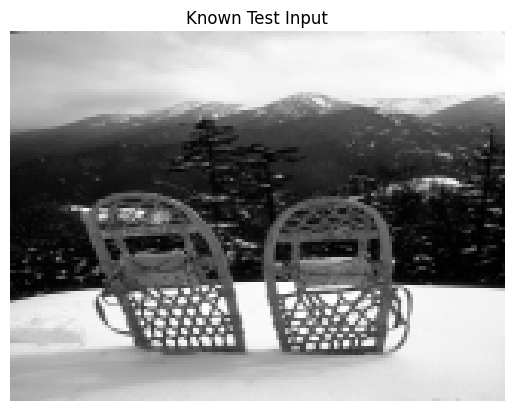

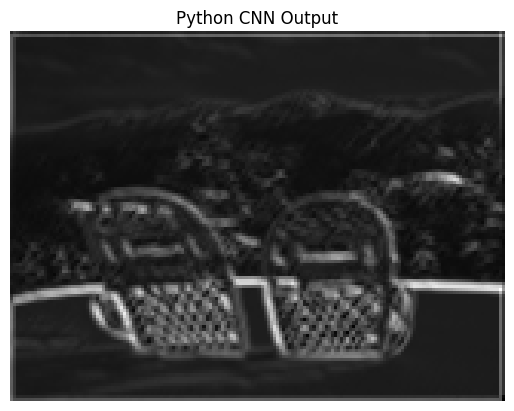

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model

# ----------------------------
# 1. Load model
# ----------------------------
model = load_model("keras_model.keras")  # change filename if needed

# ----------------------------
# 2. Find dataset images
# ----------------------------
img_path = Path(r"C:\Users\brand\Documents\engs192\zybo-edge-ai\BSDS500-master\BSDS500\data\images\test\2018.jpg")  # change this if needed

# image_files = []
# for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
#     image_files.extend(DATASET_ROOT.rglob(ext))

# print(f"Found {len(image_files)} image files.")

# for i, path in enumerate(image_files[:20]):
#     print(i, path)

# # ----------------------------
# # 3. Pick one image
# # ----------------------------
# img_path = image_files[0]
# print("Using image:", img_path)

# ----------------------------
# 4. Preprocess image
# ----------------------------
IMG_W = 162
IMG_H = 121

img = cv2.imread(str(img_path))

if img is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# OpenCV resize uses (width, height)
img_small = cv2.resize(img_gray, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)

# Normalize to 0–1
x = img_small.astype(np.float32) / 255.0

# Shape: (1, 121, 162, 1)
x = x[np.newaxis, :, :, np.newaxis]

# ----------------------------
# 5. Run Python/Keras inference
# ----------------------------
y_python = model.predict(x)

print("Known input shape:", x.shape)
print("Python output shape:", y_python.shape)
print("Input min/max:", x.min(), x.max())
print("Output min/max:", y_python.min(), y_python.max())

# ----------------------------
# 6. Save evidence files
# ----------------------------
np.save("known_test_input.npy", x)
np.save("python_output.npy", y_python)

plt.figure()
plt.imshow(x[0, :, :, 0], cmap="gray")
plt.title("Known Test Input")
plt.axis("off")
plt.savefig("known_test_input.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.imshow(y_python[0, :, :, 0], cmap="gray")
plt.title("Python CNN Output")
plt.axis("off")
plt.savefig("python_output.png", dpi=200, bbox_inches="tight")
plt.show()

In [3]:
from pathlib import Path
import numpy as np
import tensorflow as tf
import hls4ml
import cv2

# ----------------------------
# 1. Paths
# ----------------------------
model_path = Path(r"C:\Users\brand\Documents\engs192\zybo-edge-ai\FinalSprint\day1_cnn_ip_verification\keras_model.keras")
known_input_path = Path("known_test_input.npy")
python_output_path = Path("python_output.npy")

print("Model exists:", model_path.exists())
print("Known input exists:", known_input_path.exists())
print("Python output exists:", python_output_path.exists())

if not model_path.exists():
    raise FileNotFoundError(f"Could not find model: {model_path}")

if not known_input_path.exists():
    raise FileNotFoundError(f"Could not find known input: {known_input_path}")

if not python_output_path.exists():
    raise FileNotFoundError(f"Could not find Python output: {python_output_path}")

# ----------------------------
# 2. Load model and known input
# ----------------------------
model = tf.keras.models.load_model(model_path)

x = np.load(known_input_path)
y_python = np.load(python_output_path)

x = np.ascontiguousarray(x)

print("Known input shape:", x.shape)
print("Python output shape:", y_python.shape)
print("Known input min/max:", x.min(), x.max())
print("Python output min/max:", y_python.min(), y_python.max())

# ----------------------------
# 3. Build hls4ml config
# ----------------------------
# This creates a new local hls4ml project for testing.
# It does not retrain your model.
config = hls4ml.utils.config_from_keras_model(
    model,
    granularity="name"
)

# Match the report's 8-bit fixed-point stream behavior as closely as possible.
# Your csynth report shows ap_fixed<8,2> on the AXI stream arguments.
config["Model"]["Precision"] = "ap_fixed<8,2>"
config["Model"]["ReuseFactor"] = 1
config["Model"]["Strategy"] = "Resource"

# ----------------------------
# 4. Convert Keras model to hls4ml model
# ----------------------------
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    output_dir="hls4ml_one_image_test",
    backend="Vivado",
    part="xc7z020clg400-1",
    io_type="io_stream"
)

# ----------------------------
# 5. Compile and predict
# ----------------------------
hls_model.compile()

y_hls = hls_model.predict(x)

print("Raw HLS output shape:", y_hls.shape)
print("Raw HLS output min/max:", y_hls.min(), y_hls.max())

# ----------------------------
# 6. Reshape if needed
# ----------------------------
# Expected image output is 121 x 162 x 1 = 19602 values.
expected_size = 121 * 162

if y_hls.size == expected_size:
    y_hls_img = y_hls.reshape(1, 121, 162, 1)
else:
    y_hls_img = y_hls
    print("Warning: HLS output size was not 19602, so it was not reshaped.")

print("Final HLS output shape:", y_hls_img.shape)

# ----------------------------
# 7. Save hls output
# ----------------------------
np.save("hls_output.npy", y_hls_img)

# Save visual version as PNG
out = y_hls_img[0, :, :, 0]
out_norm = out - out.min()
if out_norm.max() > 0:
    out_norm = out_norm / out_norm.max()
out_png = (out_norm * 255).astype(np.uint8)
cv2.imwrite("hls_output.png", out_png)

print("Saved hls_output.npy")
print("Saved hls_output.png")

# ----------------------------
# 8. Compare Python and HLS outputs
# ----------------------------
if y_python.size == y_hls_img.size:
    diff = np.abs(y_python.flatten() - y_hls_img.flatten())
    print("Mean absolute difference:", diff.mean())
    print("Max absolute difference:", diff.max())
else:
    print("Could not compare: Python and HLS outputs have different sizes.")

Model exists: True
Known input exists: True
Python output exists: True
Known input shape: (1, 121, 162, 1)
Python output shape: (1, 121, 162, 1)
Known input min/max: 0.011764706 0.99215686
Python output min/max: -0.08689019 1.7926883
'.' is not recognized as an internal or external command,
operable program or batch file.



Exception: Failed to compile project "myproject"

## Day 1 Conclusion

The CNN IP is frozen for the next stage of the project. The known test input and Python/Keras output were generated and saved as `known_test_input.npy` and `python_output.npy`. Visual reference images were also saved as `known_test_input.png` and `python_output.png`.

The HLS synthesis report confirms that the design synthesized for the Zybo Z7-20 target device `xc7z020-clg400-1`. The top function is `myproject`, and the design uses AXI-Stream input/output with `input_image` as the input stream and `layer4_out` as the output stream. The report also shows `ap_ctrl_hs` control with `ap_start`, `ap_done`, `ap_idle`, and `ap_ready`.

The reported top-level latency is 504,947 cycles, approximately 5.049 ms, with an interval of 504,303 cycles. The reported top-level resource usage is 114 BRAM, 0 DSP, 2390 FF, and 4163 LUT. This fits on the Zybo Z7-20, although BRAM usage is significant.

A local hls4ml prediction was attempted, but `hls_model.compile()` failed with a project compile error. This does not block the Day 1 checkpoint because `hls_output.npy` is only an optional simulation comparison file. The next verification step is to use the same known input during the standalone hardware test, stream 19,602 input pixels into the CNN IP, capture 19,602 output pixels, and compare the hardware output against `python_output.npy`.

## CNN IP Block Ports

The synthesized CNN IP block has the following important top-level ports.

### Clock and Reset Ports

| Port | Direction | Purpose |
|---|---:|---|
| `ap_clk` | input | Main clock for the CNN IP |
| `ap_rst_n` | input | Active-low reset for the CNN IP |

### Control Ports

The CNN IP uses the standard HLS `ap_ctrl_hs` control interface.

| Port | Direction | Purpose |
|---|---:|---|
| `ap_start` | input | Starts one CNN inference transaction |
| `ap_done` | output | Goes high when the current inference is complete |
| `ap_idle` | output | Indicates that the IP is idle |
| `ap_ready` | output | Indicates that the IP is ready to accept a new start command |

### AXI-Stream Input Ports

The CNN input stream is named:

```text
input_image